<a href="https://colab.research.google.com/github/ADVIKA01/AdvikaMarantu_ML_Internship_2026/blob/main/AdvikaMarantu_week_3.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
pip install pandas --quiet

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
agriculture_df = pd.read_csv("agriculture.csv")

In [43]:
# STEP A:
df=pd.read_csv('agriculture.csv')
#Q1
#number of rows and columns
print("Shape:", df.shape)
#column names
print("\nColumns:", df.columns)
#first 10 records
df.head(10)

Shape: (1500, 8)

Columns: Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


In [26]:
from sklearn.metrics.pairwise import MissingValues
#Q2
#identify data type
print('\nData types')
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, "= Categorical")
    else:
        print(col, "= Numerical")
        print(df.dtypes)
#missing value
print('\nMissing Values')
print(df.isnull().sum())


Data types
rainfall_mm = Numerical
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
temperature_c = Numerical
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
fertilizer_kg = Numerical
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object
irrigation_hours = Numerical
rainfall_mm              float64
temperature_c   

In [44]:
#Q3
#summary statistics
stats = df.describe()
print(stats)
#highest mean
print("Highest mean:\n", stats.loc["mean"].idxmax())
#highest standard deviation
print("Highest std:\n", stats.loc["std"].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

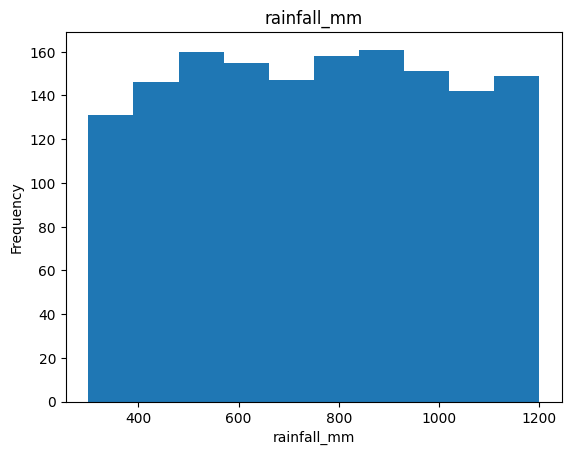

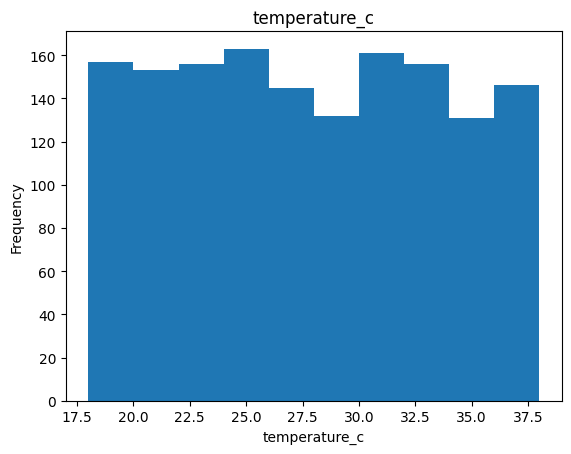

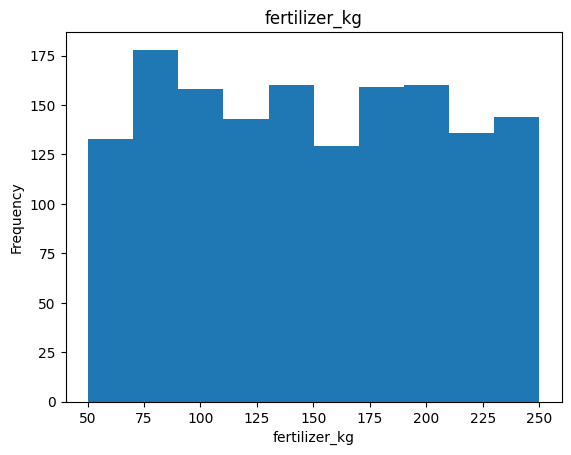

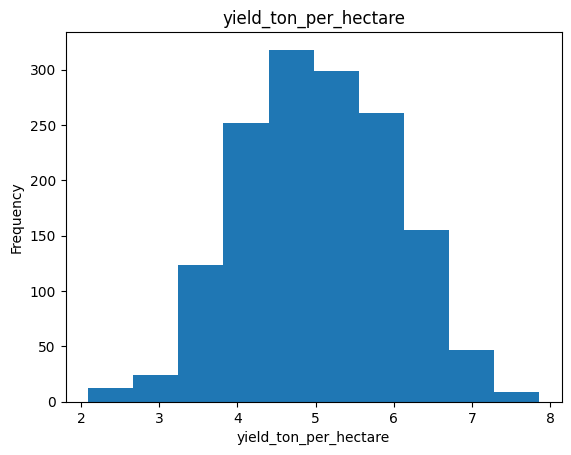

In [31]:
# STEP B:
#Q4
#exploratory data
columns = ["rainfall_mm", "temperature_c", "fertilizer_kg", "yield_ton_per_hectare"]
for col in columns:
    plt.figure()
    plt.hist(df[col])
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


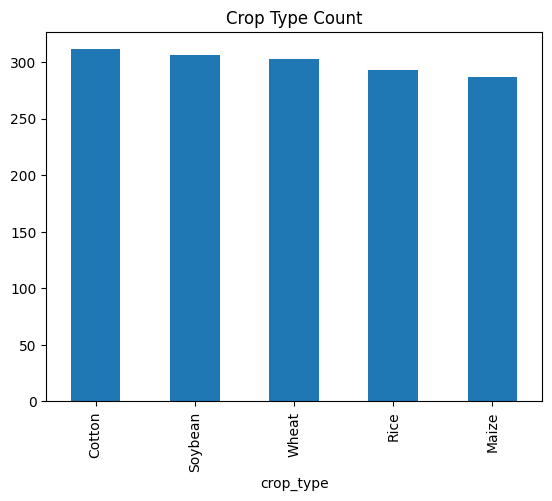

Most frequent crop: Cotton


In [42]:
#Q5
#crop type
print(df["crop_type"].value_counts())
#bar chart
df["crop_type"].value_counts().plot(kind='bar')
plt.title("Crop Type Count")
plt.show()
#most frequent crop
print("Most frequent crop:", df["crop_type"].mode()[0])

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


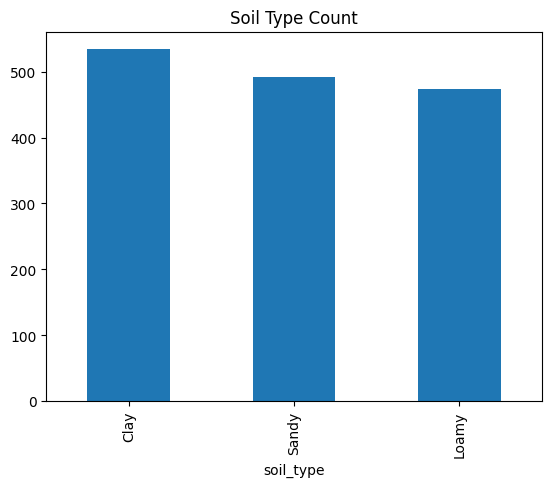

Most common soil: Clay


In [41]:
#Q6
#soil type
#frequency
print(df["soil_type"].value_counts())
#plot
df["soil_type"].value_counts().plot(kind='bar')
plt.title("Soil Type Count")
plt.show()
#most common soil
print("Most common soil:", df["soil_type"].mode()[0])

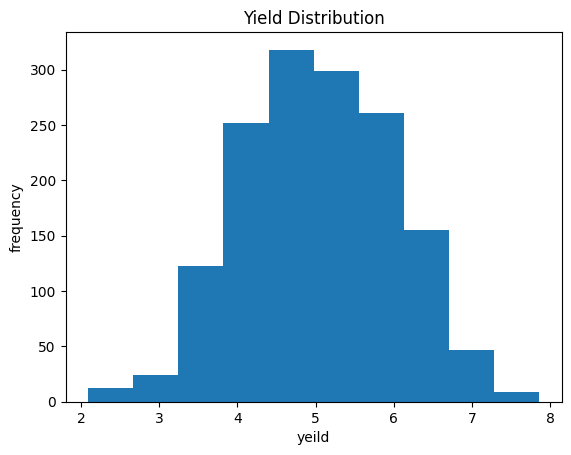

In [34]:
#Q7
#yeild distribution
plt.hist(df["yield_ton_per_hectare"])
plt.title("Yield Distribution")
plt.xlabel("yeild")
plt.ylabel("frequency")
plt.show()

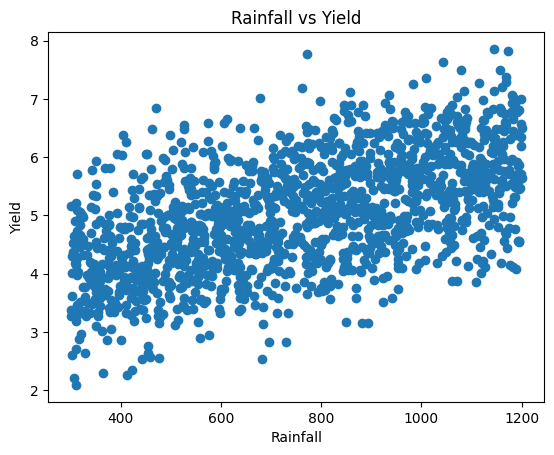

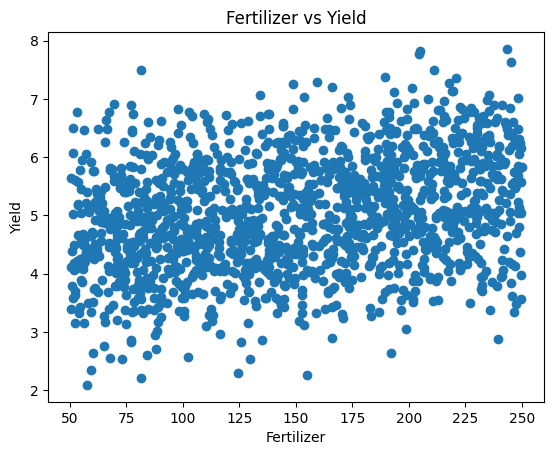

In [40]:
#Q8
#scatter plot
#rainfall vs Yield
plt.scatter(df["rainfall_mm"], df["yield_ton_per_hectare"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()
#fertilizer vs Yield
plt.scatter(df["fertilizer_kg"], df["yield_ton_per_hectare"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

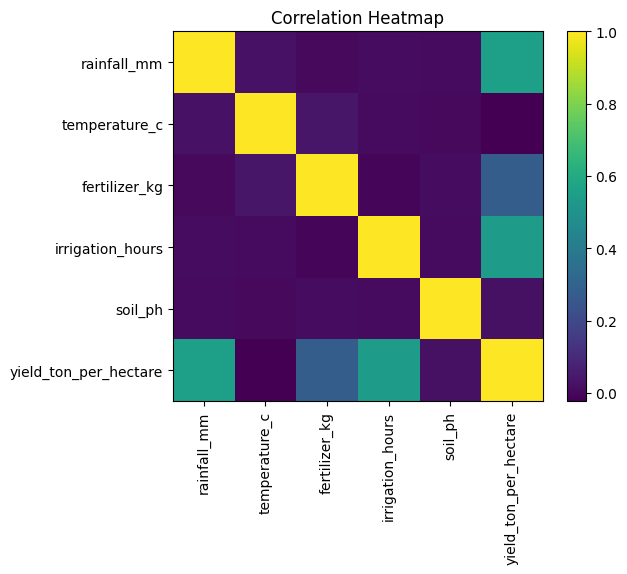

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [39]:
#Q9
#correlation
corr = df.corr(numeric_only=True)
print(corr)
#heatmap (simple)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()
#top 3 correlated with yield
print(corr["yield_ton_per_hectare"].sort_values(ascending=False))

In [38]:
#Q10
#group based analysis
#average yield by crop
print(df.groupby("crop_type")["yield_ton_per_hectare"].mean())
#average yield by soil
print(df.groupby("soil_type")["yield_ton_per_hectare"].mean())
#highest
print("Best crop:",
      df.groupby("crop_type")["yield_ton_per_hectare"].mean().idxmax())
print("Best soil:",
      df.groupby("soil_type")["yield_ton_per_hectare"].mean().idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Best crop: Rice
Best soil: Loamy


In [46]:
# STEP C:
#Q11
#check categorical columns
print(df.select_dtypes(include=['object']).columns)
#one encoding
df_encoded = pd.get_dummies(df, drop_first=True)
#show first 5 rows
df_encoded.head()

Index(['crop_type', 'soil_type'], dtype='object')


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [47]:
#Q12
#feature selection
#define X and y
X = df_encoded.drop("yield_ton_per_hectare", axis=1)
y = df_encoded["yield_ton_per_hectare"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1500, 11)
y shape: (1500,)


In [52]:
# STEP D:
#Q13
#train test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


In [51]:
#Q14
#linear regression
from sklearn.linear_model import LinearRegression
#train model
model = LinearRegression()
model.fit(X_train, y_train)
#coefficients
coeff = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_})
print(coeff)
#intercept
print("Intercept:", model.intercept_)
#feature with highest positive coefficient
print("Highest positive feature:",coeff.sort_values(by="Coefficient", ascending=False).iloc[0])

              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933
Intercept: 1.587132027736121
Highest positive feature: Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
